In [2]:
from mpi4py import MPI
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

from h5 import HDFArchive
import coqui
import coqui.dmft

Hartree_eV = 27.211386245988

--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin065 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------


Starting serial run at: 2026-06-01 13:46:07.952063
/mnt/home/cyeh/Projects/triqs/ctseg.src/build/nn_nu_0524/install/lib/python3.11/site-packages/triqs_ctseg/solver.py:7: FutureWarning: The triqs.gf module has been renamed to triqs.gfs. Please update your imports. triqs.gf will be removed in a future version.
  from .solver_core import SolverCore


## Ab Initio GW+EDMFT for Quantum Materials

<figure style="text-align: center;">
 <img src="../../images/nio_gw_edmft_summary.png" alt="Hilbert space partitioning in GW+EDMFT" width="80%">
 <figcaption><em>Figure&nbsp;1:</em> Hilbert-space partitioning in GW+EDMFT. The full single-particle space $\mathcal{B}$ is treated at the GW level, while a low-energy correlated subspace $\mathcal{C}$ is treated nonperturbatively with EDMFT. A double-counting term removes the contribution that GW already includes on $\mathcal{C}$.</figcaption>
</figure>

This tutorial introduces the ab initio GW+EDMFT workflow in CoQuí using cubic NiO as an example.

**Why go beyond GW?** As we saw in [Tutorial 02](../02_gw/02_gw_electronic_structure.ipynb), GW is a perturbative theory built on the random phase approximation (RPA). It works well for weakly to moderately correlated materials, but it breaks down when local correlations dominate the low-energy physics, such as the opening of a Mott gap or the satellite features of correlated metals. NiO is a prototypical example: a charge-transfer insulator with strong Ni $3d$–O $2p$ hybridization whose insulating gap, opened primarily in the Ni $e_g$ orbitals, is driven by local correlations that neither DFT nor GW alone fully captures. 

**Quantum embedding as the remedy.** The idea of quantum embedding is to split the Hilbert space into two parts and treat each at the level of theory it requires: a large environment $\mathcal{B}\backslash\mathcal{C}$ in which weak, nonlocal correlations dominate, and a small correlated subspace $\mathcal{C}$ in which local, nonperturbative correlations must be handled exactly. In GW+EDMFT, $\mathcal{B}$ is treated with GW and $\mathcal{C}$ is treated with *extended* dynamical mean-field theory (EDMFT), which maps the local $\mathcal{C}$ space onto an impurity problem with a dynamic local interaction $\mathcal{U}(i\Omega_n)$ in addition to the local hybridization encoded in the Weiss field $\mathcal{G}(i\omega_n)$. 

This decomposition is made rigorous by the Almbladh free-energy functional, which expresses the total free energy of the system as

$$
\Psi[G,W] \approx \Psi^{GW+\mathrm{EDMFT}}[G,W] = \Psi^{\mathrm{GW}}_{\mathcal{B}}[G,W] + \Psi^{\mathrm{EDMFT}}_{\mathcal{C}}[G,W] - \Psi^{\mathrm{DC}}_{\mathcal{C}}[G,W]. 
$$

Here, $\Psi^{\mathrm{GW}}_{\mathcal{B}}$ is the GW free energy evaluated on the full space, $\Psi^{\mathrm{EDMFT}}_{\mathcal{C}}$ adds the local EDMFT correction restricted to $\mathcal{C}$, and $\Psi^{\mathrm{DC}}_{\mathcal{C}}$ (the so-called double-counting correction) removes the part that GW has already accounted for inside $\mathcal{C}$ so that no diagram is counted twice.

**Self-consistency equations.** Stationarity of $\Psi^{\mathrm{GW+EDMFT}}$ with respect to $G$ and $W$ yields the GW+EDMFT self-consistency equations implemented in CoQui. The lattice self-energy and polarization follow from the functional derivatives $\Sigma=\delta\Psi/\delta G$ and $\Pi=-2\,\delta\Psi/\delta W$, which inside the Almbladh decomposition take the form

$$
\begin{aligned}
\Sigma^{\mathbf{k}} &= \Sigma_{\mathrm{GW}}^{\mathbf{k}} + C^{\mathbf{k}\dagger} \left[\, \tilde{\Sigma}_{\mathrm{imp}} - \tilde{\Sigma}_{\mathrm{DC}} \,\right] C^{\mathbf{k}}, \\
\Pi^{\mathbf{q}}    &= \Pi_{\mathrm{GW}}^{\mathbf{q}}    + B^{\mathbf{q}\dagger}\left[\, \tilde{\Pi}_{\mathrm{imp}}    - \tilde{\Pi}_{\mathrm{DC}}    \,\right] B^{\mathbf{q}}.
\end{aligned}
$$

Here $C^{\mathbf{k}}$ and $B^{\mathbf{q}}$ are the fermionic and bosonic projectors that map one- and two-particle quantities from the full space $\mathcal{B}$ onto the correlated subspace $\mathcal{C}$, and tildes denote quantities defined inside $\mathcal{C}$. In CoQuí, $C^{\mathbf{k}}$ is the MLWF projector and $B^{\mathbf{q}}$ is its two-particle counterpart for the bosonic (polarization / screened-interaction) channel.

The lattice GW contributions $\Sigma_{\mathrm{GW}}^{\mathbf{k}}$ and $\Pi_{\mathrm{GW}}^{\mathbf{q}}$ are evaluated on the full Hilbert space $\mathcal{B}$ using the cubic-scaling THC/ISDF algorithm of [arXiv:2401.12308](https://arxiv.org/pdf/2401.12308) (see Tutorial 02). The double-counting terms

$$
\tilde{\Sigma}_{\mathrm{DC}} = \tilde{G}_{\mathrm{loc}}\,\tilde{W}_{\mathrm{loc}}, \qquad
\tilde{\Pi}_{\mathrm{DC}}    = -\tilde{G}_{\mathrm{loc}}\,\tilde{G}_{\mathrm{loc}},
$$

represent the same GW diagrams evaluated using the *locally projected* propagators

$$
\tilde{G}_{\mathrm{loc}} = \textstyle\sum_{\mathbf{k}} C^{\mathbf{k}}\, G^{\mathbf{k}}\, C^{\mathbf{k}\dagger}, \qquad
\tilde{W}_{\mathrm{loc}} = \textstyle\sum_{\mathbf{q}} B^{\mathbf{q}}\, W^{\mathbf{q}}\, B^{\mathbf{q}\dagger},
$$

so that the bracketed corrections in the master equations above isolate the *beyond-GW* impurity contribution to the lattice self-energy and polarization.

The impurity self-energy $\tilde{\Sigma}_{\mathrm{imp}}$ and polarization $\tilde{\Pi}_{\mathrm{imp}}$ are obtained by solving an EDMFT impurity action

$$
\begin{split}
 \mathcal{S} &= \iint_0^{\beta} d\tau\, d\tau' \sum_{a,b} c^{\dagger}_{a}(\tau)\,\tilde{\mathcal{G}}^{-1}_{ab}(\tau-\tau')\,c_{b}(\tau') \\
 &+ \frac{1}{2}\iint_0^{\beta} d\tau\, d\tau' \sum_{a,b,c,d} \tilde{\mathcal{U}}_{abcd}(\tau-\tau')\, c^{\dagger}_{a}(\tau)\, c^{\dagger}_{c}(\tau')\, c_{d}(\tau')\, c_{b}(\tau),
\end{split}
$$

in which the fermionic and bosonic Weiss fields are related to the local propagators by the impurity Dyson equations

$$
\tilde{\mathcal{G}}^{-1}(i\omega_{n}) = \tilde{G}_{\mathrm{loc}}^{-1}(i\omega_{n}) + \tilde{\Sigma}_{\mathrm{imp}}(i\omega_{n}), \qquad
\tilde{\mathcal{U}}^{-1}(i\Omega_{n}) = \tilde{W}_{\mathrm{loc}}^{-1}(i\Omega_{n}) + \tilde{\Pi}_{\mathrm{imp}}(i\Omega_{n}).
$$

The action is then solved with a numerically exact continuous-time quantum Monte Carlo (CT-QMC) solver.

The EDMFT corrections $[\tilde{\Sigma}_{\mathrm{imp}} - \tilde{\Sigma}_{\mathrm{DC}}]$ and $[\tilde{\Pi}_{\mathrm{imp}} - \tilde{\Pi}_{\mathrm{DC}}]$ are then upfolded back to $\mathcal{B}$ through the projectors, after which the lattice $G^{\mathbf{k}}$ and $W^{\mathbf{q}}$ are updated through their Dyson equations 

$$
\begin{aligned}
&G^{\mathbf{k}}(i\omega_{n}) = \left[ G^{\mathbf{k},-1}_{0}(i\omega_{n}) - \Sigma^{\mathbf{k}}(i\omega_{n})\right]^{-1}\\
&W^{\mathbf{q}}(i\Omega_{n}) = \left[ V^{\mathbf{q},-1} - \Pi^{\mathbf{q}}(i\Omega_{n})\right]^{-1},
\end{aligned}
$$

which completes one iteration of the GW+EDMFT loop. 

A new iteration is started using the updated lattice propagators to compute a new GW self-energy and polarization as well as the EDMFT corrections. The procedure is iterated until 

$$
\tilde{G}_{\mathrm{loc}} = \tilde{G}_{\mathrm{imp}}, \qquad
\tilde{W}_{\mathrm{loc}} = \tilde{W}_{\mathrm{imp}}.
$$

### Section 1: Ab initio GW+EDMFT in CoQui

<figure style="text-align: center;">
 <img src="../../images/gw_edmft_cartoon.png" alt="Self-consistent GW+EDMFT workflow" width="80%">
 <figcaption><em>Figure&nbsp;2:</em> Self-consistent GW+EDMFT workflow in CoQui.</figcaption>
</figure>

Figure 2 summarizes how the ab initio GW+EDMFT self-consistency equations are organized as an iterative workflow in CoQui. The loop does not start from scratch: the initial lattice $G^{\mathbf{k}}$ and $W^{\mathbf{q}}$ are taken from a preceding GW calculation, which already provides a physically reasonable starting point for the GW+EDMFT loop. 

Starting from this initial pair $(G^{\mathbf{k}}, W^{\mathbf{q}})$, CoQui treats the lattice GW update and the impurity EDMFT update as decoupled workflow components. The GW update, shown by the yellow and green boxes in Fig. 2, computes the lattice self-energy $\Sigma_{\mathrm{GW}}^{\mathbf{k}}$ and polarization $\Pi_{\mathrm{GW}}^{\mathbf{q}}$ in the full space $\mathcal{B}$. The EDMFT update, shown by the yellow and blue boxes, projects the current lattice quantities onto the correlated subspace $\mathcal{C}$, constructs the corresponding impurity problem, and computes the impurity self-energy $\tilde{\Sigma}_{\mathrm{imp}}$ and impurity polarization $\tilde{\Pi}_{\mathrm{imp}}$. 

This separation gives users explicit control over the self-consistency strategy. For example, one may perform several GW updates before solving the impurity problem again, or perform several EDMFT impurity updates while keeping the lattice GW quantities fixed. This flexibility is useful because the lattice and impurity sectors often have different numerical costs and convergence behavior. 

>Note that CoQuí does not have its own impurity solver. Instead, an ab initio impurity problem, defined by the fermionic and bosonic Weiss fields $\tilde{\mathcal{G}}$ and $\tilde{\mathcal{U}}$, is constructed and passed to an external solver, which returns $\tilde{\Sigma}_{\mathrm{imp}}$ and $\tilde{\Pi}_{\mathrm{imp}}$ back to CoQuí for the next iteration. Currently, CoQuí interfaces with the [continuous-time quantum Monte Carlo (CT-QMC) solvers](https://github.com/TRIQS/ctseg) of the [TRIQS](https://triqs.github.io/) libraries. We will return to the specific controls for the CT-QMC solver in the GW+EDMFT execution section below.

**Outline of this notebook**

1. How to launch a GW+EDMFT calculation from a precomputed GW checkpoint using `coqui.dmft.run_gw_edmft`, and the most important input parameters that control the loop.

2. How to read and interpret the lattice (`{prefix}.mbpt.h5`) and impurity (`{prefix}.dmft.h5`) checkpoints produced by the driver.

3. How spectral functions, local self-energies, and effective interactions for NiO evolve from the GW starting point to the converged GW+EDMFT solution, and how the GW+EDMFT screened interaction compares to cRPA.

First, copy the pre-computed inputs required for this notebook.

This prepares local copies of:

- `nio_555/` (QE and Wannier90 outputs for 5x5x5 NiO)

In [3]:
%%bash
python copy_notebook_inputs.py

Copied: data/qe_inputs/nio/555 -> nio_555
Copied: data/coqui/nio/555 -> coqui_chkpts
Notebook inputs are ready.


#### 🔹 Initialization Step - GW calculation

A GW+EDMFT calculation must start from an existing GW checkpoint, which provides the initial lattice $G^{\mathbf{k}}$ and $W^{\mathbf{q}}$ for the loop. The setup of such a calculation is covered in [Tutorial 02](../02_gw/02_gw_electronic_structure.ipynb), so we will not repeat it here. 

Instead, in this tutorial, we will perform the GW+EDMFT calculation using 

- A precomputed self-consistent GW checkpoint (`coqui_chkpts/scgw/nio.mbpt.h5`) for NiO on a 5x5x5 k-mesh. 

- The MLWFs (Ni $d$ / O $p$) provided in: `nio_555/mlwf_dp/nio.mlwf.h5`. 

##### Local spectral function projected onto MLWFs
It is instructive to inspect how the MLWFs contribute to the low-energy states of the GW solution. For this purpose, we can use the post-processing routine `coqui.post_proc.local_dos` to compute the local spectral function projected onto the MLWFs (Ni $d$ / O $p$) orbitals. As we will see, this exposes the *incorrect metallic* GW solution and motivates the GW+EDMFT correction that follows.

>```python
>coqui.post_proc.local_dos(mf : Mf, params : dict)
>```

Function inputs:
- `mf`: `Mf` object of the simulation system.

- `params`: dictionary of interpolation parameters. Key parameters include:
    - `outdir` / `prefix`: GW checkpoint file, `{outdir}/{prefix}.mbpt.h5`.
    
    - `wannier_file` (required): MLWF file that defines the local subspace.

    - `w_min` / `w_max` (default: -0.367, 0.367 a.u.): real-frequency range for the spectral function.

    - `eta` (default: pi/beta a.u.): broadening applied in the analytic continuation.

Function outputs:
- The k-resolved Green's function on the uniform k-grid, projected onto the MLWFs, is written back into the same MBPT checkpoint used as input.

    - Imaginary-frequency data are stored under `scf/iter{iteration}/ac/G_wskab_fbz/input`.

    - Real-frequency continuation results are stored under `scf/iter{iteration}/ac/G_wskab_fbz/output`.

  The local spectral function can then be obtained from the real-frequency Green's function as $A(\omega) = -\frac{1}{\pi}\mathrm{Im}\,G(\omega+i\eta)$.

> Tip: `local_dos` continues the Green's function from the imaginary to the real axis with the Padé approximation by default. Since the imaginary-axis Green's function is also stored in the checkpoint, you can instead apply your own analytic-continuation workflow to the same data.

In [5]:
coqui_mpi = coqui.MpiHandler()
coqui.set_verbosity(coqui_mpi, output_level=1)

mf_params = {
    "prefix": "nio",
    "outdir": "nio_555/out",
    "nbnd": 40,
}
mf = coqui.make_mf(coqui_mpi, params=mf_params, mf_type="qe")

# Spectral functions from full-frequency self-energy
winter_params = {
    "outdir": "./coqui_chkpts/gw/",
    "prefix": "nio",
    "wannier_file": "nio_555/mlwf_dp/nio.mlwf.h5",
    "w_min": -0.30,
    "w_max": 0.20,
    "eta": 0.005, 
}
coqui.post_proc.local_dos(mf=mf, params=winter_params)

  Quantum ESPRESSO reader
  -----------------------
  Number of spins                = 1
  Number of polarizations        = 1
  Number of bands                = 40
  Monkhorst-Pack mesh            = (5,5,5)
  K-points                       = 125 total, 10 in the IBZ
  Number of electrons            = 24.0
  Electron density energy cutoff = 400.000 a.u. | FFT mesh = (36,36,36)
  Wavefunction energy cutoff     = 58.981 a.u. | FFT mesh = (19,19,19), Number of PWs = 2733

  Mesh details on the imaginary axis
  ----------------------------------
  Discrete Lehmann Representation
  Beta                   = 100.0 a.u.
  Frequency cutoff       = 5.10678741443889 a.u.
  Lambda                 = 510.678741443889
  Precision              = medium (i.e. eps = 1e-10)
  nt_f, nt_b, nw_f, nw_b = 44, 44, 44, 45

  Projector Information
  ---------------------
  Number of impurities                      = 1
  Number of local orbitals per impurity     = 8
  Range of primary orbitals for local basis = [5

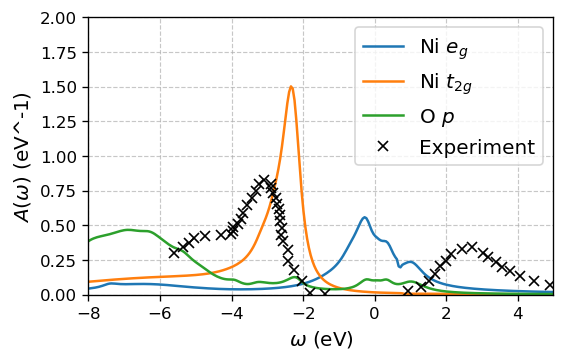

In [ ]:
with HDFArchive("coqui_chkpts/gw/nio.mbpt.h5", "r") as ar:
    w_mesh = ar["scf/iter8/ac/G_wskab_fbz/w_mesh"] * Hartree_eV
    Gw = ar["scf/iter8/ac/G_wskab_fbz/output"] / Hartree_eV
    
Aloc = -np.sum(Gw.imag, axis=(1, 2)) / Gw.shape[2] / np.pi
A_eg = Aloc[:,0] + Aloc[:,1]
A_t2g = Aloc[:,2] + Aloc[:,3] + Aloc[:,4]
A_p = Aloc[:,5] + Aloc[:,6] + Aloc[:,7]

# read photoemission data
tot_pes = np.load("coqui_chkpts/expt/nio_pes.npy")
tot_xas = np.load("coqui_chkpts/expt/nio_xas.npy")

fig, ax = plt.subplots(1, figsize=(5,3), dpi=120)
ax.plot(w_mesh.real, A_eg, label='Ni $e_g$')
ax.plot(w_mesh.real, A_t2g, label='Ni $t_{2g}$')
ax.plot(w_mesh.real, A_p, label='O $p$')
ax.plot(tot_pes[:,0], tot_pes[:,1], color='black', marker='x', linestyle='', label='Experiment')
ax.plot(tot_xas[:,0], tot_xas[:,1], color='black', marker='x', linestyle='')

ax.set_xlim(-8.0, 5.0)
ax.set_ylim(0, 2.0)
ax.set_xlabel(r"$\omega$ (eV)", fontsize=12)
ax.set_ylabel(r"$A(\omega)$ (eV^-1)", fontsize=12)
ax.legend(ncol=1, loc=1, fontsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
plt.show()

The plot above shows the GW local spectral function projected onto the Ni $e_g$, Ni $t_{2g}$, and O $p$ MLWFs. Two observations are relevant for setting up the GW+EDMFT calculation. First, the Ni $3d$ and O $2p$ weight strongly overlap over a wide energy window, reflecting the substantial $d$–$p$ hybridization characteristic of charge-transfer materials. Second, the Ni $e_g$ manifold and O $p$ orbitals both have finite spectral weight at the Fermi level, in contrast to the experimentally observed insulating state.

Based on this observation, we define the correlated subspace $\mathcal{C}$ to consist of only the Ni $e_g$ MLWFs (stored in `nio_555/mlwf_dp/nio_eg.mlwf.h5`). These orbitals dominates the low-energy spectral weight at the Fermi level and are the primary orbitals in which the Mott gap is expected to open. 
The remaining Ni $t_{2g}$ and O $p$ degrees of freedom are retained in the $GW$ level. 

#### 🔹 GW+EDMFT execution

Starting from a GW checkpoint and a correlated subspace $\mathcal{C}$ defined by the MLWFs, a GW+EDMFT calculation is launched by calling the single `coqui.dmft.run_gw_edmft` function: 

> ```
> coqui.dmft.run_gw_edmft(h_int: ThcCoulomb, embedding: ModEST.Embedding, params: dict)
> ```

Function inputs:
- `h_int`: `ThcCoulomb` instance containing the lattice Coulomb Hamiltonian used in the GW updates.

- `embedding`: `ModEST.Embedding` instance which describes the mapping between the MLWF space and the set of impurity problems.

- `params`: dictionary containing the GW+EDMFT run settings. The most important entries for this tutorial are:

    - `outdir` (default: `"./"`): output directory for the generated checkpoint files.

    - `prefix` (required): file prefix used for the checkpoint `{prefix}.mbpt.h5`.

    - `niter` (required): number of outer GW+EDMFT iterations to perform.

    - `gw_iter_per_loop` (default: 1): number of GW updates per outer GW+EDMFT iteration. 

    - `edmft_iter_per_loop` (default: 1): number of EDMFT impurity updates per outer GW+EDMFT iteration.

    - `wannier_file` (required): MLWF HDF5 archive that defines the correlated subspace $\mathcal{C}$. 

    - `screen_type` (default: `"gw_edmft"`): screening prescription used to build the lattice irreducible polarization.

    - `edmft["chkpt_h5"]` (optional; default: write impurity data into `{outdir}/{prefix}.mbpt.h5`): redirect the impurity inputs and solver results to a separate HDF5 file. 

    - `edmft["impurity"]` (required): impurity-solver configuration block. See the note below for the most important CT-SEG controls.

> When `screen_type="rpa"`, polarization is updated using the RPA expression:
>$$
\Pi^{\mathbf{q}} = -\textstyle\sum_{\mathbf{k}} G^{\mathbf{k}} G^{\mathbf{k}+\mathbf{q}}
 $$
>without adding the EDMFT correction. As a consequence, the bosonic EDMFT self-consistency condition is no longer enforced: 
>$$
\tilde{W}_{\mathrm{loc}} \neq \tilde{W}_{\mathrm{imp}}.
 $$
>The EDMFT correction to the self-energy is still included, so the fermionic self-consistency condition
>$$
\tilde{G}_{\mathrm{loc}} = \tilde{G}_{\mathrm{imp}}
 $$
>is still imposed. This simplified scheme is useful for stabilizing the initial stage of a GW+EDMFT iteration. In early iterations especially for Mott insulators, the impurity polarization can be unstable especially for the bosonic Weiss field is far from converged. This allows the fermionic EDMFT loop to relax first. Once the calculation is stable, one can then switch to the full GW+EDMFT screening update.  

> **Note on the impurity solver.** The EDMFT step solves a quantum impurity model with retarded interations. CoQuí drives this via [TRIQS/ctseg](https://github.com/TRIQS/ctseg/tree/unstable), a continuous-time hybridization-expansion quantum Monte Carlo solver, which natively supports density–density retarded interactions. The CT-SEG controls you will most often touch — all set inside `edmft["impurity"]` — fall into three groups:
>
> - **Monte Carlo statistics** (`n_cycles`, `n_warmup_cycles`, `length_cycle`): total measurement cycles across MPI, warmup cycles for equilibration, and updates between successive measurements. Together they set the statistical error on $\tilde{\Sigma}_{\mathrm{imp}}$ and $\tilde{\Pi}_{\mathrm{imp}}$.
>
> - **High-frequency tail fit** (`perform_tail_fit`, `fit_min_w`, `fit_max_w`, `fit_max_moment`): fit the noisy high-Matsubara tail of $\tilde{\Sigma}_{\mathrm{imp}}$ with an analytic $\mathcal{O}(1/i\omega_n)$ form. The fit is performed in the frequency window [`fit_min_w`, `fit_max_w`] with $\mathcal{O}(1/i\omega_n)$ up to order `fit_max_moment`. The high-frequency part of the self-energy (i.e. $w \ge $`fit_min_w`) is then replaced by the fit function. 
>
> - **Chemical-potential adjustment** (`chemical_potential["tolerance"]` and related sub-controls): at every EDMFT iteration, an inner search adjusts the impurity chemical potential so that the impurity occupancy matches the projected lattice value, and `"tolerance"` sets the allowed mismatch in that *occupancy difference*. This is *not* a convergence criterion for the full GW+EDMFT self-consistency; it acts as a *pre-conditioner* that stabilizes the impurity solution. It can be switched off and a converged solution can still be reached, but enabling it is recommended — especially in the early iterations, where the impurity problem is rather different from the local quantities. 
  
> **Trouble shooting tip**: 
> 1. If the EDMFT convergence does not get improved after increasing the number of Monte Carlo cycles systematically, you might need to revisit your tail fitting parameters: adjust the frequency window [`fit_min_w`, `fit_max_w`] or the fit order `fit_max_moment`. Poor tail fitting can introduce a systematic error in the self-energy, preventing the EDMFT loop from converging below a certain accuracy even when the Monte Carlo sampling is sufficiently long.
>
> 2. If the chemical-potential tolerance is set too tightly relative to the QMC statistical accuracy, the chemical-potential search may become unreliable. The impurity occupancy fluctuates within the Monte Carlo error bar, so the root-finding procedure cannot reliably distinguish changes smaller than this noise level.

Output:
- `{outdir}/{prefix}.mbpt.h5`: lattice checkpoint containing $G^{\mathbf{k}}$, $W^{\mathbf{q}}$, $\Sigma^{\mathbf{k}}$, $\Pi^{\mathbf{q}}$ and related quantities needed for post-processing and restart of the lattice side of the loop. By default, the impurity inputs and solver results are also appended to this file, so a single archive holds the complete state of the calculation.

- `edmft["chkpt_h5"]` (optional): present only when `edmft["chkpt_h5"]` is set; in that case the impurity inputs and solver results are written here instead of being appended to the MBPT archive.

> For complete parameter options, use `help(coqui.dmft.run_gw_edmft)`. A full working setup used in this tutorial is collected in `gw_edmft.py`.

#### 🔹 Example - running a toy GW+EDMFT calculation for NiO

This is a deliberately small **toy** calculation: its purpose is to give you first-hand experience of launching and monitoring an actual GW+EDMFT run, not to produce converged results. The rest of this notebook instead reads a *pre-computed, converged* checkpoint (provided under `coqui_chkpts/`) for the analysis, so you can explore the physics without waiting for a full calculation to converge.

> the CT-QMC controls (`n_cycles`, `n_warmup_cycles`, `length_cycle`) are deliberately undersampled — the resulting $\tilde{\Sigma}_{\mathrm{imp}}$ and $\tilde{\Pi}_{\mathrm{imp}}$ will be noisier than in a production calculation. 

Now we are ready to launch the GW+EDMFT calculation for NiO. 

Since the CT-QMC impurity solver is rather costly, we launch the calculation externally with MPI parallelization rather than calling `run_gw_edmft` directly inside the notebook. The full Python script is collected in `gw_edmft.py`.

In [1]:
!cat gw_edmft.py

import triqs.utility.mpi as mpi
import triqs_modest as modest

import coqui
import coqui.dmft

coqui_mpi = coqui.MpiHandler()
coqui.set_verbosity(coqui_mpi, output_level=1)

# Define correlated subspace via ModEST
wan_h5 = "nio_555/mlwf_dp/nio_eg.mlwf.h5"
obe = modest.make_one_body_elements_gw(wan_h5)
E1 = modest.make_embedding(obe.C_space)

mf_params = {"prefix": "nio", "outdir": "nio_555/out", "nbnd": 40}
mf = coqui.make_mf(coqui_mpi, params=mf_params, mf_type='qe')

thc_params = {
  "ecut": 1.2 * mf.ecutwfc(),
  "thresh": 1e-3, 
  "save": "thc.coulomb.h5"
}
thc = coqui.make_thc_coulomb(mf=mf, params=thc_params)

gw_edmft_params = {
  "outdir": "./coqui_chkpts/gw/",
  "prefix": "nio",
  "niter": 4,
  "wannier_file": wan_h5,
  "screen_type": "rpa",
  "edmft": {
    "chkpt_h5": "nio.dmft.h5",
    "impurity": [
        {
         "degenerate_blk_thresh": 0.001,
         "length_cycle": 50,
         "n_warmup_cycles": 5e4,
         "n_cycles": 1e6,
         "perform_tail_fit": True,
    

Run `gw_edmft.py` parallel by executing the following command in the terminal: 

In [ ]:
!mpirun -np 4 python gw.py

#### 🔹 Reading the EDMFT checkpoint

Once the run completes, the impurity inputs and solver results live in `edmft["chkpt_h5"]` (here `nio.dmft.h5`) and the lattice quantities live in `{outdir}/{prefix}.mbpt.h5`. Inside the impurity archive, the EDMFT data are organized by iteration and by impurity index:

```
nio.dmft.h5
├── dmft/
│   ├── iter0/
│   │   └── impurity_0/
│   │       ├── inputs/        # Gloc(τ), Wloc(τ), 𝒢, 𝒰, Vloc, ...
│   │       └── results/       # Σ_imp, Π_imp, Σ_imp − Σ_DC, Π_imp − Π_DC, ...
│   ├── iter1/...
│   └── ...
└── imaginary_fourier_transform/   # DLR mesh metadata
```

The `imaginary_fourier_transform/` group stores the DLR basis metadata needed to interpret the imaginary-time and Matsubara-frequency quantities under each iteration; it is read automatically when you construct an `IAFT` object (see Tutorial 03 for an introduction).

A quick first pass at the archive — useful for sanity-checking that the file is well-formed and for seeing which iterations are present — is to print its top-level structure directly through `HDFArchive`:

>```python
>from h5 import HDFArchive
>with HDFArchive("nio.dmft.h5", "r") as ar:
>    print(ar)
>```

For postprocessing it is more convenient to use the helper `coqui.dmft.read_impurity_chkpt`, which returns Python dicts for a chosen iteration:

>```python
>coqui.dmft.read_impurity_chkpt(
>    h5_filename: str,
>    iteration: int = -1,
>    read: str = "both",
>) -> Tuple[List[dict], List[dict]]
>```

Function inputs:
- `h5_filename` (required): path to the impurity HDF5 checkpoint file.

- `iteration` (default `-1`): EDMFT iteration to read; `-1` selects the last iteration.

- `read` (default `"both"`): which data to return — `"inputs"`, `"results"`, or `"both"`.

Function output: a list of dicts (one per impurity) when `read` is `"inputs"` or `"results"`, or a tuple `(results_list, inputs_list)` when `read="both"`. The dict for each impurity contains:

- **Inputs** — the data the solver was handed at that iteration: the local Green's function and screened interaction in imaginary time (`Gloc_t`, `Wloc_t`), the fermionic and bosonic Weiss fields (`g_weiss_iw`, `u_weiss_iw`), and the bare local interaction (`Vloc`).

- **Results** — the data the solver produced: the impurity self-energy and polarization on the DLR mesh (`Sigma_iw`, `Pi_iw`) and on a uniform Matsubara grid (`Sigma_iw_data`, `Pi_iw_data`), their double-counting counterparts (`Sigma_iw_dc_data`, `Pi_iw_dc_data`), the impurity Green's function and screened interaction (`G_iw_data`, `W_iw_data`), the static Hartree–Fock parts (`Sigma_infty`, `Sigma_infty_dc`), and the Green's-function block structure (`gf_struct`).

#### 🔹 Convergence analysis

The GW+EDMFT cycle has reached its fixed point when the locally projected lattice quantities coincide with their impurity counterparts, $\tilde{G}_{\mathrm{loc}} = \tilde{G}_{\mathrm{imp}}$ and $\tilde{W}_{\mathrm{loc}} = \tilde{W}_{\mathrm{imp}}$. In practice we monitor a small set of indicators iteration by iteration to gauge how the loop is approaching this condition:

- $|\tilde{G}_{\mathrm{loc}} - \tilde{G}_{\mathrm{imp}}|$ and $|\tilde{W}_{\mathrm{loc}} - \tilde{W}_{\mathrm{imp}}|$: the primary self-consistency indicators.

- $|\Delta \tilde{\mathcal{G}}|$ and $|\Delta \tilde{\mathcal{U}}|$: iteration-to-iteration changes of the fermionic and bosonic Weiss fields, useful for diagnosing slow mixing or oscillations.

- $n_{\mathrm{imp}}$: total occupation, which should settle as the loop converges.

- $\mu_{\mathrm{imp}}$: the impurity chemical potential shift relative to the chemical potential of the full system, which should approach zero as the loop converges.

- $\tilde{\mathcal{U}}(\omega=0)$: the static value of the impurity screened interaction, a quick read on whether the loop is drifting toward a physically reasonable solution.

CoQuí ships a convenience plotter `coqui.dmft.plot_edmft_convergence` that pulls these quantities from an EDMFT checkpoint and writes them to a multi-panel PNG:

>```python
>coqui.dmft.plot_edmft_convergence(
>    dmft_chkpt: str,
>    *,
>    impurity_index: int = 0,
>    check_w: bool = True,
>    figure_name: str = "edmft_convergence",
>) -> str
>```

Function inputs:
- `dmft_chkpt` (required): path to the EDMFT HDF5 checkpoint.

- `impurity_index` (default `0`): which impurity in the embedding to plot. Only relevant when the embedding contains more than one impurity.

- `check_w` (default `True`): include the $|\tilde{W}_{\mathrm{loc}} - \tilde{W}_{\mathrm{imp}}|$ panel. 

- `figure_name` (default `"edmft_convergence"`): output filename prefix; the function appends `_imp{impurity_index}.png`.

Function output: the path of the written PNG file.

#### 🔹 Example 

In this example, we will call `coqui.dmft.plot_edmft_convergence` on the pre-generated GW+EDMFT checkpoint `nio.dmft.h5` which contains about 30 iterations of GW+EDMFT for NiO. 

Starting serial run at: 2026-06-01 00:15:38.168898
/mnt/home/cyeh/Projects/triqs/ctseg.src/build/nn_nu_0524/install/lib/python3.11/site-packages/triqs_ctseg/solver.py:7: FutureWarning: The triqs.gf module has been renamed to triqs.gfs. Please update your imports. triqs.gf will be removed in a future version.
  from .solver_core import SolverCore


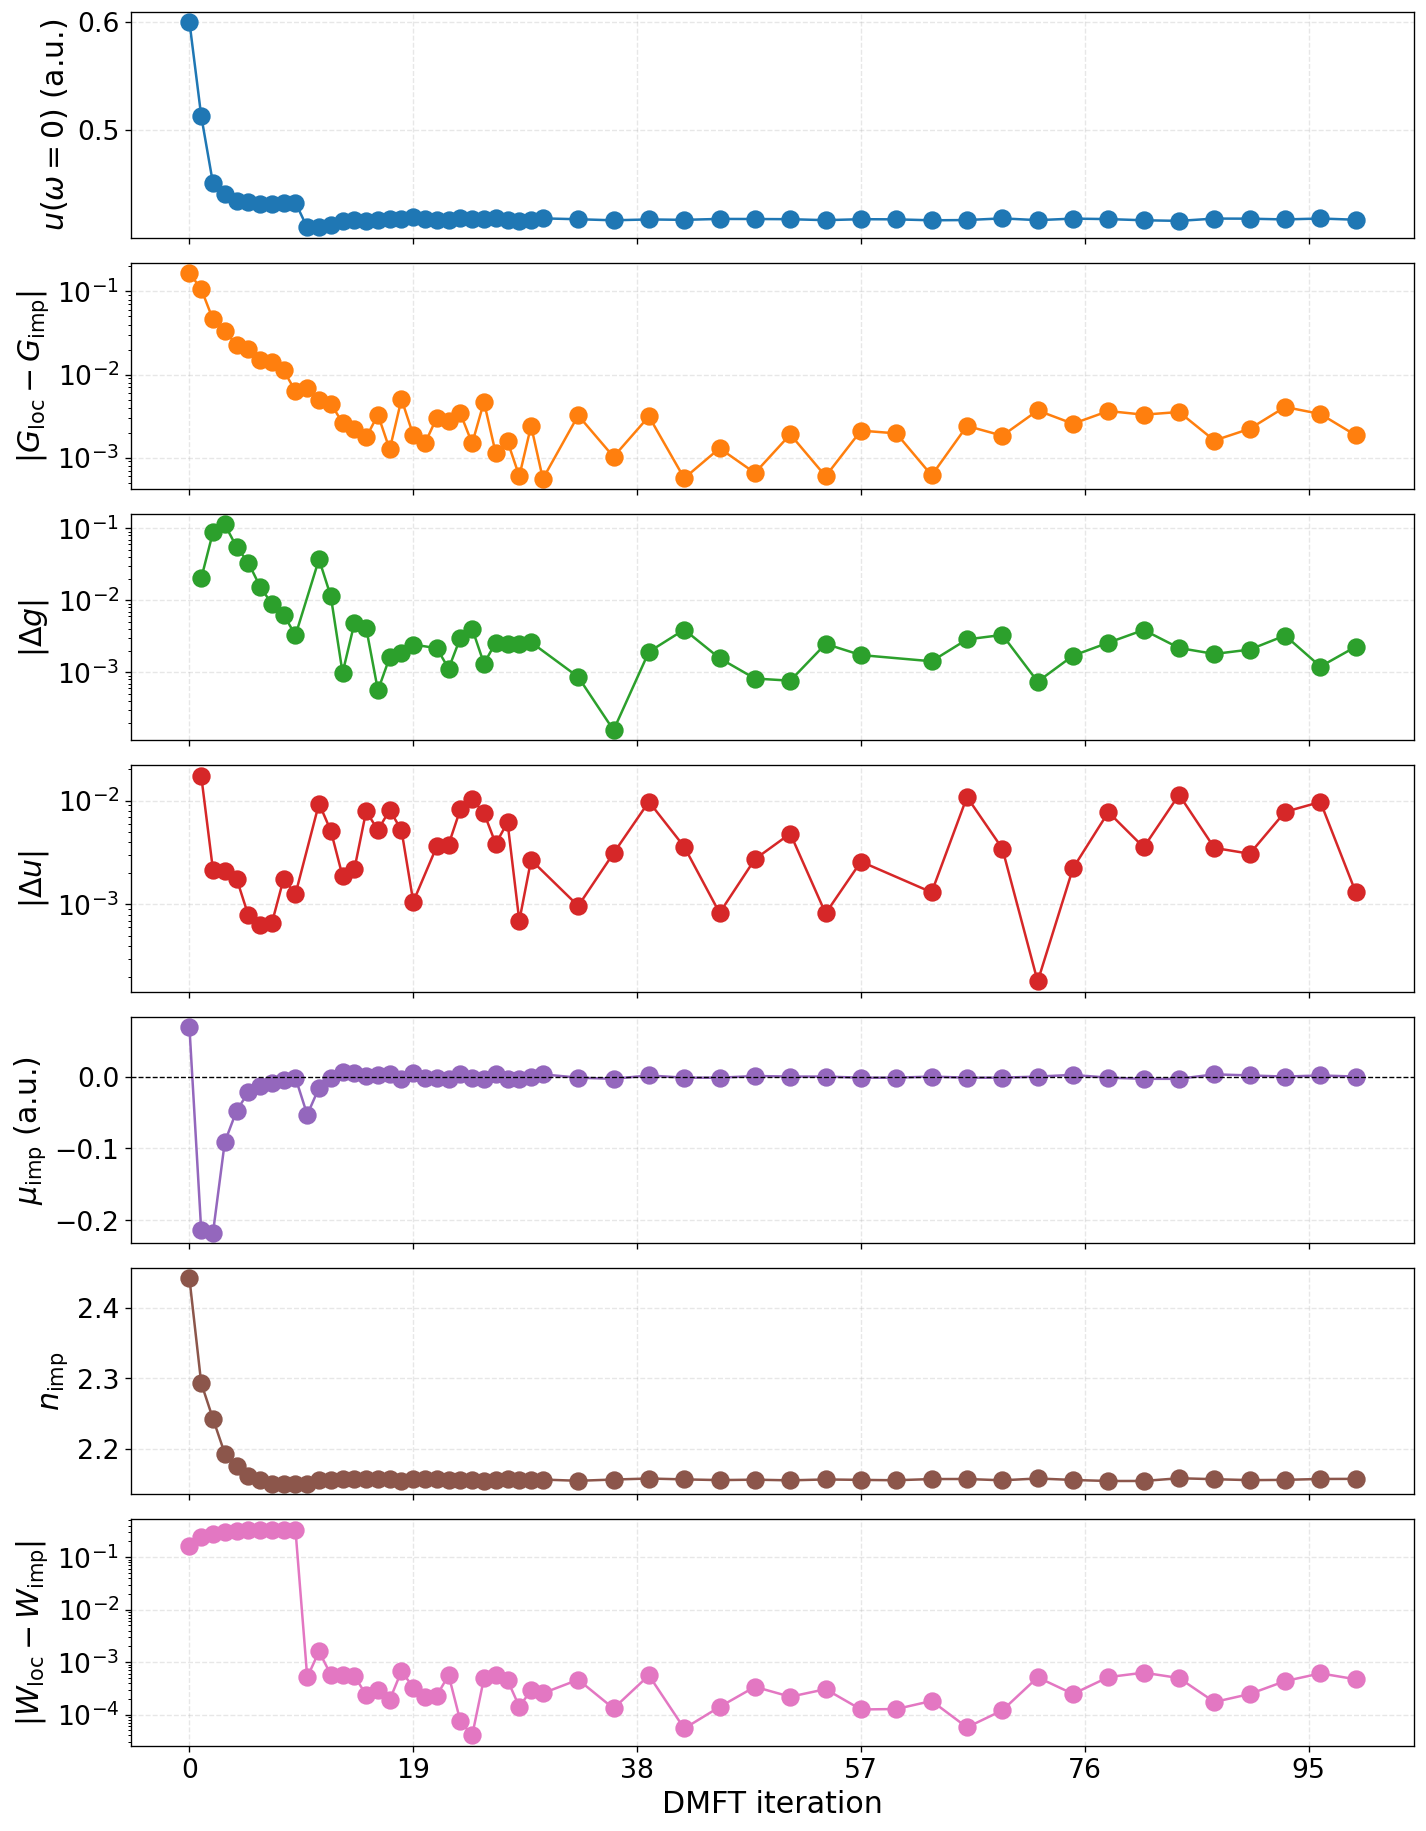

In [ ]:
from IPython.display import display, Image

dmft_chkpt = "coqui_chkpts/gw_edmft/nio.dmft.h5"
out_file = coqui.dmft.plot_edmft_convergence(dmft_chkpt, check_w=True)
display(Image(out_file, width=600))

# this is needed for matplotlib to display plots in the remaining notebook cells (or workaround?)
%matplotlib inline 

A few features of the convergence figure above are worth reading off:

- **Two-stage screening.** This run used `rpa` screening for the first 10 iterations and switched on the self-consistent `gw_edmft` screening only afterwards. That is why $|\tilde{W}_{\mathrm{loc}} - \tilde{W}_{\mathrm{imp}}|$ stays large through the first 10 iterations — the lattice screened interaction is not yet being iterated against the impurity — and only starts to converge once the EDMFT polarization correction is turned on.

- **Charge stabilization.** The impurity occupation $n_{\mathrm{imp}}$ settles to a stable value while the auxiliary impurity chemical potential $\mu_{\mathrm{imp}}$ decays toward zero, signalling that the impurity charge has become consistent with the projected lattice value.

- **Self-energy vs. polarization.** Most of the change in $n_{\mathrm{imp}}$ is driven by the EDMFT correction to the *self-energy*; once the EDMFT correction to the *polarization* is also included (after iteration 10), the occupation barely moves. For NiO, the local self-energy correction is the dominant effect on the charge distribution.

### Section 2: Analysis of GW+EDMFT results

In Section 1 we launched a short GW+EDMFT run for NiO and saw where the lattice and impurity quantities are stored. We now turn to the physics: using a converged NiO checkpoint, we examine how the EDMFT correction reshapes the local electronic structure relative to the GW starting point. The analysis proceeds in four steps:

1. the impurity self-energy and polarization, and how their EDMFT corrections differ from the double-counting (GW-level) terms;

2. the local spectral function, compared between $GW$, $GW$+EDMFT, and experiment;

3. the local screened interaction $W$, compared across $G_0W_0$, self-consistent $GW$, and GW+EDMFT;

4. the effective impurity interaction $\mathcal{U}$, compared with cRPA.

Further applications and analysis of ab initio GW+EDMFT for real materials can be found in [arXiv:2603.12336](https://arxiv.org/pdf/2603.12336), which applied the same CoQuí workflow to the correlated oxides SrMnO$_3$ and LaNiO$_3$.

Throughout this section we load quantities from the converged impurity checkpoint with the `coqui.dmft.read_impurity_chkpt` helper introduced in Section 1. Recall that it returns one dictionary per impurity for a chosen iteration: `read="inputs"` returns the quantities handed to the solver (e.g. `Gloc_t`, `Wloc_t`, the Weiss fields, `Vloc`), while `read="results"` returns the quantities the solver produced (e.g. `Sigma_iw_data`, `Pi_iw_data` and their double-counting counterparts, `G_iw_data`, `W_iw_data`). In the cell below we read the *inputs* at the first iteration (`iteration=0`, i.e. the GW-level quantities that seed the impurity problem) and the *results* at the last iteration (`iteration=-1`, the converged impurity solution); the trailing `[0]` selects the first (and, here, only) impurity. The two `print` statements list the keys available in each dictionary.

In [5]:
dmft_chkpt = "coqui_chkpts/gw_edmft/nio.dmft.h5"
iaft = coqui.IAFT.from_coqui_chkpt(dmft_chkpt)
imp_inputs = coqui.dmft.read_impurity_chkpt(dmft_chkpt, read="inputs", iteration=0)[0]
imp_results = coqui.dmft.read_impurity_chkpt(dmft_chkpt, read="results", iteration=-1)[0]

print("Keys in impurity inputs dictionary:")
print(imp_inputs.keys())
print("\nKeys in impurity results dictionary:")
print(imp_results.keys())

Keys in impurity inputs dictionary:
dict_keys(['Gloc_t', 'Vloc', 'Wloc_t', 'delta_iw', 'g_weiss_iw', 'gf_struct', 'h0', 'u_weiss_iw'])

Keys in impurity results dictionary:
dict_keys(['Chi_iw', 'G_iw', 'G_iw_data', 'Pi_iw', 'Pi_iw_data', 'Pi_iw_dc_data', 'Sigma_infty', 'Sigma_infty_dc', 'Sigma_iw', 'Sigma_iw_data', 'Sigma_iw_dc_data', 'W_iw', 'W_iw_data', 'average_order', 'average_sign', 'convergence', 'density', 'gf_struct', 'mu_imp', 'orbital_occupations'])


#### 🔹 Impurity solutions

The plots below compare the converged impurity self-energy $\tilde{\Sigma}_{\mathrm{imp}}$ and polarization $\tilde{\Pi}_{\mathrm{imp}}$ with their double-counting counterparts $\tilde{\Sigma}_{\mathrm{DC}}$ and $\tilde{\Pi}_{\mathrm{DC}}$. 

It is important to distinguish the impurity quantities themselves from the EDMFT corrections embedded back into the lattice. The EDMFT corrections are not $\tilde{\Sigma}_{\mathrm{imp}}$ and $\tilde{\Pi}_{\mathrm{imp}}$ directly, but rather the differences

$$
\tilde{\Sigma}_{\mathrm{imp}} - \tilde{\Sigma}_{\mathrm{DC}},
\qquad
\tilde{\Pi}_{\mathrm{imp}} - \tilde{\Pi}_{\mathrm{DC}} .
$$

The double-counting terms represent the local GW/RPA contributions that are already included in the lattice calculation. Therefore, these differences isolate the additional local vertex corrections supplied by the EDMFT impurity problem beyond GW/RPA.

- **Self-energy — opening the Mott gap.** As $i\omega_n \to 0$, $\mathrm{Im}\,\tilde{\Sigma}_{\mathrm{imp}}$ bends sharply downward, indicating the formation of a low-frequency pole $\tilde{\Sigma}(\omega) \sim \Delta^2 / \omega$ in the Ni $e_g$ self-energy. This pole splits the $e_g$ states into lower and upper Hubbard bands and opens the Mott gap. By contrast, the double-counting self-energy $\tilde{\Sigma}_{\mathrm{DC}}$, which represents the GW-level local self-energy, remains finite at low frequency. 

- **Polarization — suppressed local charge fluctuations.** The impurity polarization $\tilde{\Pi}_{\mathrm{imp}}$ is smaller in magnitude than the double-counting $\tilde{\Pi}_{\mathrm{DC}}$. This smaller magnitude of $\tilde{\Pi}_{\mathrm{imp}}$ suggests that the local vertex corrections suppress the local charge response relative to the RPA description. As a result, the EDMFT correction reduces the local screening strength and increases the local screened interaction compared with the GW/RPA result. 

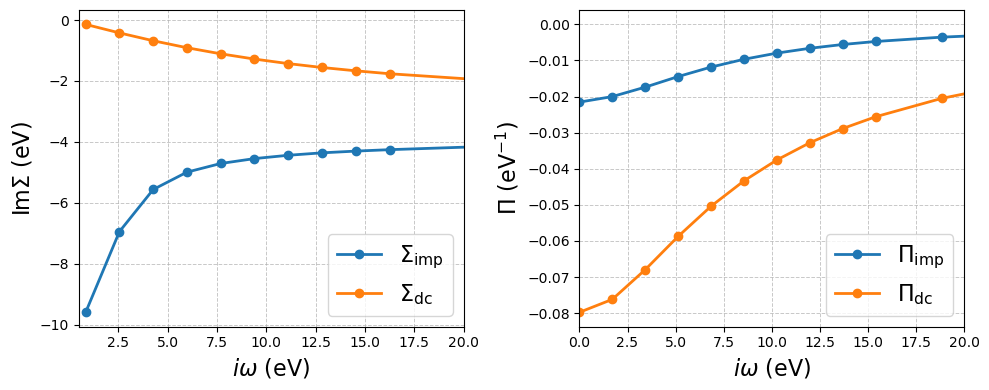

In [7]:
# extract impurity and double-counting self-energy on the Matsubara frequency axis
iw_mesh_f = iaft.wn_mesh('fermion') * np.pi / iaft.beta * Hartree_eV
Sigma_imp_iw = imp_results['Sigma_iw_data'][0][iw_mesh_f>0,0,0] * Hartree_eV
Sigma_dc_iw = imp_results['Sigma_iw_dc_data'][0][iw_mesh_f>0,0,0] * Hartree_eV
iw_mesh_f = iw_mesh_f[iw_mesh_f>0]# * np.pi / iaft.beta * Hartree_eV

# extract impurity and double-counting polarization on the Matsubara frequency axis
iw_mesh_b = iaft.wn_mesh('boson', positive_only=True) * np.pi / iaft.beta * Hartree_eV
Pi_imp_iw = imp_results['Pi_iw_data'][  0][:,0,0] / Hartree_eV
Pi_dc_iw = imp_results['Pi_iw_dc_data'][  0][:,0,0] / Hartree_eV

# plotting
fig, ax = plt.subplots(1, 2, figsize=(10,4), dpi=100)
offset = 0
ax[0].plot(iw_mesh_f, Sigma_imp_iw.imag, 
     linestyle='-', marker='o', markersize=6, linewidth=2, 
     label=r'$\Sigma_{\mathrm{imp}}$')
ax[0].plot(iw_mesh_f, Sigma_dc_iw.imag, 
     linestyle='-', marker='o', markersize=6, linewidth=2, 
     label=r'$\Sigma_{\mathrm{dc}}$')
ax[1].plot(iw_mesh_b, Pi_imp_iw.real, 
     linestyle='-', marker='o', markersize=6, linewidth=2, 
     label=r'$\Pi_{\mathrm{imp}}$')
ax[1].plot(iw_mesh_b, Pi_dc_iw.real, 
     linestyle='-', marker='o', markersize=6, linewidth=2, 
     label=r'$\Pi_{\mathrm{dc}}$')

ax[0].set_xlim(0.5, 20.0)
ax[0].set_xlabel(r"$i\omega$ (eV)", fontsize=16)
ax[0].set_ylabel(r"Im$\Sigma$ (eV)", fontsize=16)
ax[0].legend(loc=4, ncol=1, fontsize=16)
ax[0].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

ax[1].set_xlim(0.0, 20.0)
#ax[1].set_ylim(-10.0, 1.0)
ax[1].set_xlabel(r"$i\omega$ (eV)", fontsize=16)
ax[1].set_ylabel(r"$\Pi$ (eV$^{-1}$)", fontsize=16)
ax[1].legend(loc=4, ncol=1, fontsize=16)
ax[1].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
 
plt.tight_layout()
plt.show()

#### 🔹 Local spectral functions: GW vs. GW+EDMFT vs. experiment

To see the consequence of this self-energy pole on the spectrum, we analytically continue the local Green's function to the real axis (here with Padé) and compare the resulting Ni $e_g$ spectral function $A(\omega) = -\frac{1}{\pi}\mathrm{Im}\,G(\omega + i\eta)$ at the GW and GW+EDMFT levels against experiment. The experimental curve combines photoemission (PES), which probes the occupied states at $\omega < 0$, with x-ray absorption (XAS), which probes the unoccupied states at $\omega > 0$.

At the GW level, $A(\omega)$ retains finite weight at the Fermi level, noted in Section 1. GW+EDMFT instead opens a gap and redistributes the $e_g$ weight into lower and upper Hubbard bands, in good agreement with the measured PES and XAS peak positions. This is the central result of the calculation: the local correlations captured by EDMFT turn the incorrectly metallic GW solution into the Mott insulator observed in experiment without any empirical parameters. 

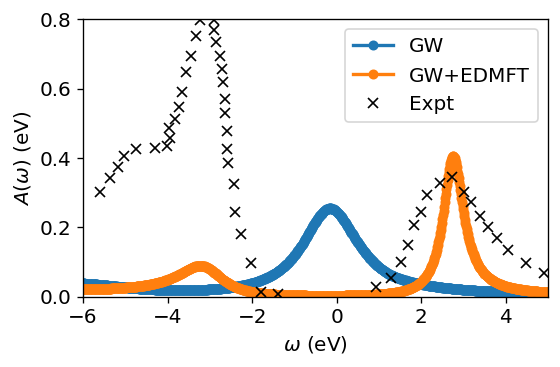

In [8]:
# Extract Gloc from G0W0 and Gimp from GW+EDMFT, and then perform AC to real-frequency axis. 
Gloc_iw_gw = iaft.tau_to_w(imp_inputs["Gloc_t"][0], stats='fermion')
Gimp_iw = imp_results["G_iw_data"][0]

Gw_gw, w_mesh = coqui.post_proc.pade(Gloc_iw_gw, iaft, stats='fermion', wmin=-0.3, wmax=0.20, Nw=1000, Nfit=100, eta=0.005)
Gw, w_mesh = coqui.post_proc.pade(Gimp_iw, iaft, stats='fermion', wmin=-0.3, wmax=0.20, Nw=1000, Nfit=100, eta=0.005)

# extract spectroscopy experimental data
tot_pes = np.load("coqui_chkpts/expt/nio_pes.npy")
tot_xas = np.load("coqui_chkpts/expt/nio_xas.npy")

fig, ax = plt.subplots(1, figsize=(5,3), dpi=120)
ax.plot(w_mesh.real * Hartree_eV, -Gw_gw[:,0,0].imag / (np.pi * Hartree_eV),
        linewidth=2, marker='o', markersize=5, label='GW')
ax.plot(w_mesh.real * Hartree_eV, -Gw[:,0,0].imag / (np.pi * Hartree_eV),
        linewidth=2, marker='o', markersize=5, label='GW+EDMFT')
ax.plot(tot_pes[:,0], tot_pes[:,1], color='black', marker='x', linestyle='', label='Expt')
ax.plot(tot_xas[:,0], tot_xas[:,1], color='black', marker='x', linestyle='')

ax.set_xlim(-6.0, 5.0)
ax.set_ylim(0, 0.8)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xlabel(r'$\omega$ (eV)', fontsize=12)
ax.set_ylabel(r'$A(\omega)$ (eV)', fontsize=12)
ax.legend(fontsize=12)
plt.show()

#### 🔹 Local spectrum of the impurity screened interaction

The screened interaction is sensitive to the underlying electronic structure, so it gives a complementary view of how self-consistency and local correlations reshape the low-energy physics. Here we compare the local screened interaction $W_{\mathrm{loc}}$ at three levels — one-shot $G_0W_0$, self-consistent GW (scGW), and GW+EDMFT.

At low frequency the $G_0W_0$ and scGW curves are very similar: both screen with a metallic electronic structure, which over-screens the interaction and pins the static value $W_{\mathrm{loc}}(\omega=0)$ to roughly 2 eV. GW+EDMFT is qualitatively different. Once the EDMFT correction opens the Mott gap, the low-energy particle–hole screening channel is strongly suppressed, and the static screened interaction is enhanced from about 2 eV to roughly 8 eV. This large difference highlights how sensitively the screened interaction depends on whether the underlying electronic structure is (incorrectly) metallic or correctly gapped.

The same comparison continued to the real-frequency axis is shown below, separating the dissipative ($-\mathrm{Im}\,W$) and reactive ($\mathrm{Re}\,W$) parts of the screened interaction.

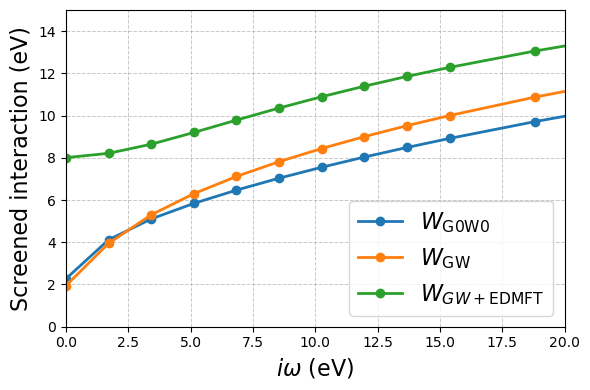

In [9]:
# read W_loc of G0W0 and scGW from the provided checkpoint 
with HDFArchive("coqui_chkpts/gw/nio.mbpt.h5", "r") as ar:
    V_bare    = ar["scf/iter1/downfolded_model/Vloc_abcd"][0,0,0,0] #* Hartree_eV
    W_g0w0_iw = ar["scf/iter1/downfolded_model/Uloc_wabcd"][:,0,0,0,0] #* Hartree_eV
    W_gw_iw   = ar["scf/iter8/downfolded_model/Uloc_wabcd"][:,0,0,0,0] #* Hartree_eV

# read impurity inputs in the last GW+EDMFT iteration to get bosonic Weiss field
W_gw_edmft_iw = imp_results["W_iw_data"][0][:,0,0] #* Hartree_eV
iw_mesh_b = iaft.wn_mesh('boson', positive_only=True) * np.pi / iaft.beta #* Hartree_eV

fig, ax = plt.subplots(1, figsize=(6,4), dpi=100)
ax.plot(iw_mesh_b * Hartree_eV, (W_g0w0_iw+V_bare).real * Hartree_eV, 
        marker='o', markersize=6, linewidth=2, label=r'$W_{\mathrm{G0W0}}$')
ax.plot(iw_mesh_b * Hartree_eV, (W_gw_iw+V_bare).real * Hartree_eV, 
        marker='o', markersize=6, linewidth=2, label=r'$W_{\mathrm{GW}}$')
ax.plot(iw_mesh_b * Hartree_eV, (W_gw_edmft_iw+V_bare).real * Hartree_eV, 
        marker='o', markersize=6, linewidth=2, label=r'$W_{GW+\mathrm{EDMFT}}$')

ax.set_xlim(0.0, 20.0)
ax.set_ylim(0.0, 15.0)
ax.set_xlabel(r"$i\omega$ (eV)", fontsize=16)
ax.set_ylabel("Screened interaction (eV)", fontsize=16)
ax.legend(loc=4, ncol=1, fontsize=16)
ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
 
plt.tight_layout()
plt.show()

The spectral function of $W$, which can be expressed in terms of the bare interaction $V$ and the polarization $\Pi(\omega)$ as

$$
-\mathrm{Im}W(\omega) = \frac{V^{2}\mathrm{Im}\,\Pi(\omega)}{|1 - V\mathrm{Re}\Pi(\omega)|^{2} + V^{2}|\Pi(\omega)|^2}
$$

is closely coupled with the *charge* excitation spectrums obtained from $\Pi(\omega)$.

In Mott insulators, the low-energy charge fluctuations are suppressed due to strong local correlations, which implies little spectral weight at low frequency. Physically, this means charge excitations require overcoming the Mott gap, and screening becomes ineffective at low energies. This is reflected in the GW+EDMFT $W(\omega)$, which has a much smaller amplitude at low frequency than the GW-level $W(\omega)$.

The main feature of the GW+EDMFT $W(\omega)$ is the opening of a charge gap: spectral weight is suppressed at low frequency, and screening sets in only around 4.5 eV, reflecting the low-energy charge excitations across the correlated insulating gap.

In the metallic GW solution (both $G_{0}W_{0}$ and self-consistent $GW$), the local polarization contains a gapless particle-hole continuum originating from low-energy excitations across the Fermi surface. This continuum produces spectral weight in $W$ down to zero frequency. The EDMFT Mott solution restores the charge gap, suppresses low-energy screening, and allows discrete/structured charge-transfer and local screening features to emerge.

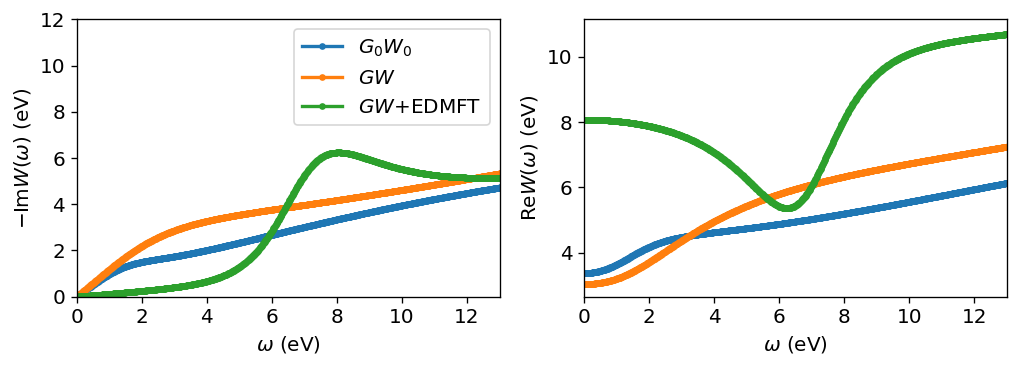

In [12]:
# Analytic continuation of screened interations W to real-frequency axis 
wmin, wmax, Nw = 0.0, 0.5, 1000
W_g0w0_w, w_mesh = coqui.post_proc.pade(
    W_g0w0_iw, iaft, stats='boson', wmin=wmin, wmax=wmax, Nw=Nw, Nfit=50, ph_sym=True 
)
W_gw_w, w_mesh = coqui.post_proc.pade(
    W_gw_iw, iaft, stats='boson', wmin=wmin, wmax=wmax, Nw=Nw, Nfit=50, ph_sym=True
)
W_gw_edmft_w, w_mesh = coqui.post_proc.pade(
    W_gw_edmft_iw, iaft, stats='boson', wmin=wmin, wmax=wmax, Nw=Nw, Nfit=50, ph_sym=True
)

# plot the real-frequency W
fig, ax = plt.subplots(1, 2, figsize=(10,3), dpi=120)
ax[0].plot(w_mesh.real * Hartree_eV, -W_g0w0_w.imag * Hartree_eV,
        linewidth=2, marker='o', markersize=3, label='$G_{0}W_{0}$')
ax[0].plot(w_mesh.real * Hartree_eV, -W_gw_w.imag * Hartree_eV,
        linewidth=2, marker='o', markersize=3, label='$GW$')
ax[0].plot(w_mesh.real * Hartree_eV, -W_gw_edmft_w.imag * Hartree_eV,
        linewidth=2, marker='o', markersize=3, label='$GW$+EDMFT')
ax[1].plot(w_mesh.real * Hartree_eV, (W_g0w0_w+V_bare).real * Hartree_eV,
        linewidth=2, marker='o', markersize=3, label='$G_{0}W_{0}$')
ax[1].plot(w_mesh.real * Hartree_eV, (W_gw_w+V_bare).real * Hartree_eV,
        linewidth=2, marker='o', markersize=3, label='$GW$')
ax[1].plot(w_mesh.real * Hartree_eV, (W_gw_edmft_w+V_bare).real * Hartree_eV,
        linewidth=2, marker='o', markersize=3, label='$GW$+EDMFT')
ax[0].set_xlim(0.0, 13.0)
ax[0].set_ylim(0, 12.0)
ax[0].tick_params(axis='both', which='major', labelsize=12)
ax[0].set_xlabel(r'$\omega$ (eV)', fontsize=12)
ax[0].set_ylabel(r'$-\mathrm{Im}W(\omega)$ (eV)', fontsize=12)
ax[0].legend(fontsize=12)

ax[1].set_xlim(0.0, 13.0)
ax[1].tick_params(axis='both', which='major', labelsize=12)
ax[1].set_xlabel(r'$\omega$ (eV)', fontsize=12)
ax[1].set_ylabel(r'$\mathrm{Re}W(\omega)$ (eV)', fontsize=12)
plt.show()

#### 🔹 Effective interactions and its comparison with cRPA

<figure style="text-align: center;">
 <img src="../../images/gw_edmft_hilbert_space.png" alt="screening types" width="50%">
 <figcaption><em>Figure&nbsp;3:</em> Different types of screening processes involving transitions between $\mathcal{B}$ and $\mathcal{C}$: (1) transitions between $\mathcal{C}$ and $\mathcal{B}\backslash\mathcal{C}$, (2) transitions within the environment $\mathcal{B}\backslash\mathcal{C}$, and (3) transitions within the subspace $\mathcal{C}$.</figcaption>
</figure>

A common way to define the effective interaction for a low-energy model is cRPA ([Tutorial 03](../03_crpa/03_crpa_screened_interactions.ipynb)), which removes the screening channels internal to $\mathcal{C}$ (process 3 in the figure) but keeps the remaining channels at the RPA level. The bosonic Weiss field $\mathcal{U}$ that the GW+EDMFT impurity experiences plays the analogous role, but is determined self-consistently in the presence of the EDMFT corrections. Comparing the two, the GW+EDMFT effective interaction comes out substantially larger than the cRPA one, for two reasons:

1. **Reference electronic structure.** Screening depends strongly on the electronic structure used to evaluate it. The cRPA interaction here is built on the metallic GW reference, which over-screens all the processes in the figure; once GW+EDMFT opens the gap, those channels are weaker and the resulting interaction is larger.

2. **Local vertex corrections.** The impurity polarization entering $\mathcal{U}$ includes local vertex corrections beyond RPA, which further suppress the screening and push the effective interaction up.

Together these effects mean that an interaction parameter taken from cRPA can significantly underestimate the effective interaction appropriate for a self-consistent quantum-embedding calculation.

> Note: This is consistent with common practice in DFT+DMFT studies of NiO, where the on-site interaction is typically taken to be $U \sim 7$–$10$ eV and $J \sim 1.0$ eV ([see, e.g., this reference](https://arxiv.org/pdf/1612.07571)) — values much closer to the GW+EDMFT $\mathcal{U}$ obtained here than to the cRPA estimate.

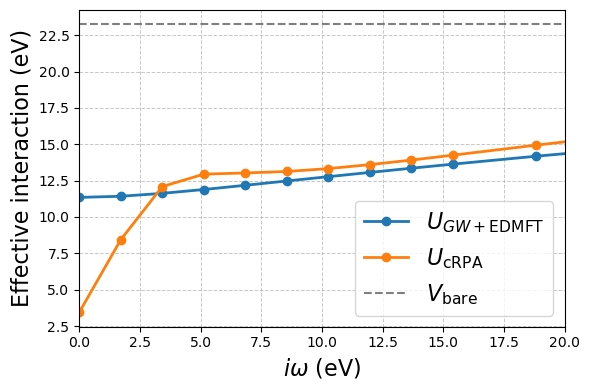

In [6]:
# read cRPA interaction from the provided checkpoint 
with HDFArchive("coqui_chkpts/crpa/crpa.mbpt.h5", "r") as ar:
    V_bare = ar["scf/iter0/downfolded_model/Vloc_abcd"][0,0,0,0] * Hartree_eV
    Ucrpa_iw = ar["scf/iter0/downfolded_model/Uloc_wabcd"][:,0,0,0,0] * Hartree_eV

# read impurity inputs in the last GW+EDMFT iteration to get bosonic Weiss field
imp_inputs = coqui.dmft.read_impurity_chkpt(dmft_chkpt, read="inputs", iteration=-1)[0]
u_weiss_iw = imp_inputs["u_weiss_iw"][:,0,0,0,0] * Hartree_eV

iw_mesh_b = iaft.wn_mesh('boson', positive_only=True) * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(1, figsize=(6,4), dpi=100)
ax.plot(iw_mesh_b, (u_weiss_iw+V_bare).real, marker='o', markersize=6, linewidth=2, label=r'$U_{GW+\mathrm{EDMFT}}$')
ax.plot(iw_mesh_b, (Ucrpa_iw+V_bare).real, marker='o', markersize=6, linewidth=2, label=r'$U_{\mathrm{cRPA}}$')
ax.axhline(y=V_bare.real, color='black', linestyle='--', alpha=0.5, label=r'$V_{\mathrm{bare}}$')

ax.set_xlim(0.0, 20.0)
ax.set_xlabel(r"$i\omega$ (eV)", fontsize=16)
ax.set_ylabel("Effective interaction (eV)", fontsize=16)
ax.legend(loc=4, ncol=1, fontsize=16)
ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
 
plt.tight_layout()
plt.show()